# 구독 서비스의 성장 지표 확인하기 — MRR 분석 실습

Google Play Sales Report와 비슷한 형태의 결제 로그 하나만 가지고,
본문에서 다룬 MRR 분석 파이프라인을 처음부터 끝까지 재현합니다.

1. `order_number`에서 유저를 식별하고 (본문 2.4.1)
2. renew와 reactivation을 구분한 뒤 (본문 2.4.3)
3. 월별 MRR을 new / renew / reactivation / expansion / contraction / churn으로 분해하고 (본문 2.3, 2.4.2)
4. GRR과 NRR로 매출 유지력을 진단합니다 (본문 2.4.6)
5. 같은 로직을 '사람 수' 단위로 반복해 매출 단위 집계와의 차이를 확인하고 (본문 2.4.7)
6. 데이터에 심어 둔 정답(월 이탈률 5%)을 복원하며 본문 '정리하며'의 LTV 어림식으로 연결합니다.

체험(Trial) 흐름, 연구독 안분(retained MRR), 환불 처리는 본문 설명으로 갈음하고 실습에서는 다루지 않습니다.

## 0. 준비

In [1]:
%pip install -q -r requirements.txt


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/leo/leo-project/bye-summer/book2/.claude/skills/style-alignment/venv/bin/python -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

# 차트에 한글이 섞여도 깨지지 않도록 폰트 설정 (라벨 자체는 영어를 사용)
if sys.platform.startswith("win"):
    plt.rcParams["font.family"] = "Malgun Gothic"
elif sys.platform == "darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

con = duckdb.connect()
con.execute("CREATE TABLE sales AS SELECT * FROM read_csv_auto('data/subscription_sales.csv')")
con.execute("SELECT count(*) AS rows, min(order_charged_date) AS first, max(order_charged_date) AS last FROM sales").df()

,rows,first,last
0,10653,2025-01-01,2026-06-28


### 결제 로그 살펴보기

이 실습의 유일한 원천 데이터입니다. 실제 스토어 리포트처럼 **유저 ID 컬럼이 없습니다.**
첫 결제는 `order_number`에 suffix가 없고, 갱신 결제부터 `..1`, `..2`가 붙습니다.

In [3]:
con.execute("SELECT * FROM sales ORDER BY order_charged_date LIMIT 5").df()

,order_number,order_charged_date,product_id,sales_amount_krw
0,GPA.3473-2940-6316-10023,2025-01-01,monthly_basic,4900
1,GPA.4592-1953-7554-10053,2025-01-02,monthly_basic,4900
2,GPA.7136-4072-6031-10032,2025-01-02,monthly_basic,4900
3,GPA.9603-9106-3123-10049,2025-01-02,monthly_basic,4900
4,GPA.5376-7591-3453-10048,2025-01-03,monthly_plus,9900


## 실습 1. order_number에서 유저 식별하기

`'..'` 앞부분(prefix)이 같으면 동일 유저입니다. prefix로 유저를 묶고,
`row_number()`로 유저별 누적 결제 회차(`order_cnt`)를 계산합니다.
suffix가 0, 1, null 등 어떤 형태로 오더라도 결제일 순서로 다시 세기 때문에 안전합니다.

이 유저 식별 결과는 다음 단계들이 계속 재사용하므로, orders 뷰로 만들어 둡니다.

In [4]:
con.execute("""
    CREATE OR REPLACE VIEW orders AS
    SELECT
        split_part(order_number, '..', 1)  AS pid
      , order_charged_date
      , product_id
      , sales_amount_krw
      , row_number() OVER (PARTITION BY split_part(order_number, '..', 1)
                           ORDER BY order_charged_date) AS order_cnt
    FROM sales
""")
orders = con.execute("SELECT * FROM orders").df()
n_orders = orders.groupby("pid").size()
print(f"유저 수: {orders.pid.nunique():,}명 / 결제 건수: {len(orders):,}건")
print(f"유저별 결제 횟수: 최소 {n_orders.min()}회 ~ 최대 {n_orders.max()}회")
n_orders.value_counts().sort_index()

유저 수: 1,653명 / 결제 건수: 10,653건
유저별 결제 횟수: 최소 1회 ~ 최대 18회


1     198
2     179
3     169
4     149
5     134
6     126
7     114
8      93
9      85
10     72
11     75
12     62
13     45
14     41
15     35
16     29
17     22
18     25
Name: count, dtype: int64

## 실습 2. renew와 reactivation 구분하기

`LAG()`로 직전 결제일을 가져와 간격을 잽니다. 월구독 주기는 약 30일이니
**직전 결제와의 간격이 32일 미만이면 renew, 그 이상이면 reactivation**으로 분류합니다.

[내 데이터 적용] 결제 주기가 월 단위가 아니면 32일 임계값을 주기에 맞게 바꿉니다.
연구독처럼 주기가 긴 상품은 이 방식이 맞지 않으므로 본문 2.4.4를 참고하세요.

분류 결과도 classified 뷰로 만들어 두면, 실습 3의 MRR 분해 쿼리가 그대로 가져다 쓸 수 있습니다.

In [5]:
con.execute("""
    CREATE OR REPLACE VIEW classified AS
    SELECT *
         , CASE WHEN order_cnt = 1 THEN 'new'
                WHEN date_diff('day', prev_date, order_charged_date) < 32 THEN 'renew'
                ELSE 'reactivation' END AS pay_type
    FROM (SELECT *
               , lag(order_charged_date) OVER (PARTITION BY pid
                                               ORDER BY order_charged_date) AS prev_date
          FROM orders)
""")
classified = con.execute("SELECT * FROM classified").df()
classified.pay_type.value_counts()

pay_type
renew           8961
new             1653
reactivation      39
Name: count, dtype: int64

분류가 잘 됐는지 결제 간격의 분포로 확인해 봅니다.
renew는 28~31일(월 주기)에 몰려 있고, reactivation은 최소 한 달 이상의 공백 뒤에 나타나야 정상입니다.

In [6]:
gap = (pd.to_datetime(classified.order_charged_date)
       - pd.to_datetime(classified.prev_date)).dt.days
for t in ["renew", "reactivation"]:
    g = gap[classified.pay_type == t]
    print(f"{t:14s} 간격: {g.min():.0f} ~ {g.max():.0f}일 (중앙값 {g.median():.0f}일)")

renew          간격: 28 ~ 31일 (중앙값 31일)
reactivation   간격: 44 ~ 396일 (중앙값 160일)


## 실습 3. 월별 MRR 분해

유저×월 단위로 결제를 모은 뒤 **전월과 FULL OUTER JOIN** 합니다.

- 양쪽 모두 결제가 있으면 → 계속 구독 (재결제 금액이 늘어난 부분은 expansion, 줄어든 부분은 contraction, 남은 유지분은 renew)
- 이번 달에만 있으면 → new 또는 reactivation
- 전월에만 있으면 → **churn** (본문 2.4.2에서 설명한 '패시브 이벤트' — 결제하지 않음으로써 드러납니다)

같은 쿼리를 `sql/mrr_breakdown.sql` 파일로도 넣어 두었습니다.

먼저 유저×월 단위 집계를 monthly 뷰로 만들어 둡니다.

In [7]:
con.execute("""
    CREATE OR REPLACE VIEW monthly AS
    -- 유저×월 집계: 같은 달 결제가 여러 건(월중 플랜 변경 등)이어도 한 행으로 합친다
    SELECT
        pid
      , date_trunc('month', order_charged_date) AS month
      , sum(sales_amount_krw) AS amt
      , min(pay_type)         AS pay_type   -- 우선순위 new > reactivation > renew (알파벳순과 우연히 일치)
    FROM classified
    GROUP BY pid, month
""")

In [8]:
query = """
WITH paired AS (   -- 유저×월을 전월과 짝지어 세 가지 상태를 가른다
    SELECT
        coalesce(c.month, p.month + INTERVAL 1 MONTH) AS month
      , c.amt        AS amt        -- 이번 달 결제액 (없으면 NULL = 이탈)
      , p.amt        AS prev_amt   -- 전월 결제액 (없으면 NULL = 신규/복귀)
      , c.pay_type
    FROM monthly c
    FULL OUTER JOIN monthly p
      ON c.pid = p.pid AND p.month = c.month - INTERVAL 1 MONTH
)
SELECT
    month
  , sum(amt)                                                        AS mrr
  , sum(CASE WHEN pay_type = 'new'          THEN amt END)           AS new_mrr
  , sum(CASE WHEN pay_type = 'reactivation' THEN amt END)           AS reactivation_mrr
  , sum(CASE WHEN amt IS NOT NULL AND prev_amt IS NOT NULL
             THEN least(amt, prev_amt) END)                         AS renew_mrr
  , sum(CASE WHEN amt IS NOT NULL AND prev_amt IS NOT NULL
             THEN greatest(amt - prev_amt, 0) END)                  AS expansion_mrr
  , sum(CASE WHEN amt IS NOT NULL AND prev_amt IS NOT NULL
             THEN greatest(prev_amt - amt, 0) END)                  AS contraction_mrr
  , sum(CASE WHEN amt IS NULL THEN prev_amt END)                    AS churn_mrr
  , sum(prev_amt)                                                   AS baseline_mrr
FROM paired
WHERE month <= (SELECT max(month) FROM monthly)   -- 데이터 종료 이후의 유령 월 제거
GROUP BY month
ORDER BY month
"""
mrr = con.execute(query).df().fillna(0)
mrr["month"] = pd.to_datetime(mrr["month"]).dt.to_period("M").astype(str)
mrr = mrr.iloc[1:].reset_index(drop=True)   # 첫 달은 전월이 없어 분해가 안 되므로 제외
mrr.tail(6)

,month,mrr,new_mrr,reactivation_mrr,renew_mrr,expansion_mrr,contraction_mrr,churn_mrr,baseline_mrr
11,2026-01,5039000.0,659100.0,44500.0,4285400.0,50000.0,10000.0,196800.0,4492200.0
12,2026-02,5680800.0,783500.0,14700.0,4797600.0,85000.0,5000.0,236400.0,5039000.0
13,2026-03,6108800.0,753000.0,29500.0,5301300.0,25000.0,5000.0,374500.0,5680800.0
14,2026-04,6561000.0,712800.0,34400.0,5783800.0,30000.0,20000.0,305000.0,6108800.0
15,2026-05,7136700.0,747000.0,29500.0,6270200.0,90000.0,25000.0,265800.0,6561000.0
16,2026-06,7608900.0,811700.0,49300.0,6707900.0,40000.0,25000.0,403800.0,7136700.0


본문의 수식이 실제로 성립하는지 확인해 봅니다.

**MRR = 전월 MRR(Baseline) + new + reactivation + expansion − contraction − churn**

In [9]:
check = (mrr.baseline_mrr + mrr.new_mrr + mrr.reactivation_mrr
         + mrr.expansion_mrr - mrr.contraction_mrr - mrr.churn_mrr)
print("항등식 최대 오차:", (mrr.mrr - check).abs().max(), "원")

항등식 최대 오차: 0.0 원


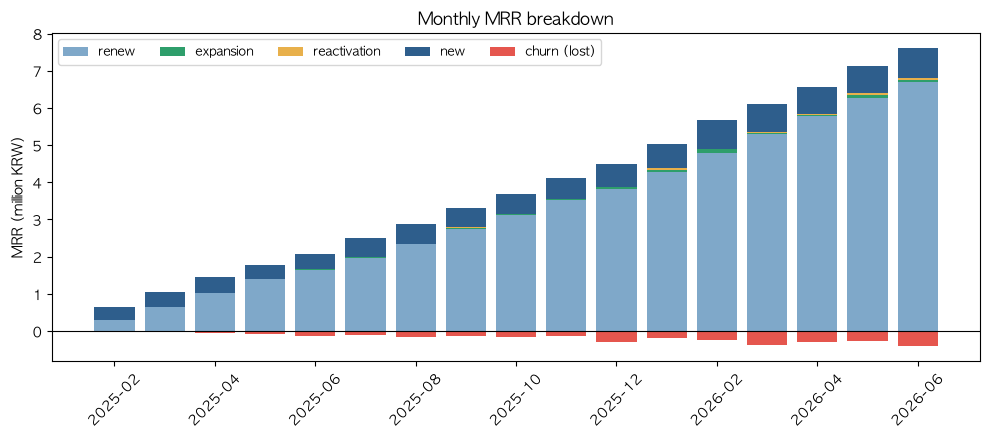

In [10]:
# MRR 구성 스택 차트 — renew 위에 expansion/reactivation/new가 쌓이고, churn은 음수로 표시
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(mrr))
bottom = np.zeros(len(mrr))
colors = {"renew_mrr": "#7FA8C9", "expansion_mrr": "#2E9E6B",
          "reactivation_mrr": "#E8B04B", "new_mrr": "#2E5E8C"}
for col, c in colors.items():
    ax.bar(x, mrr[col] / 1e6, bottom=bottom, color=c, label=col.replace("_mrr", ""))
    bottom += mrr[col].to_numpy() / 1e6
ax.bar(x, -mrr.churn_mrr / 1e6, color="#E5564E", label="churn (lost)")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x[::2]); ax.set_xticklabels(mrr.month[::2], rotation=45)
ax.set_ylabel("MRR (million KRW)")
ax.set_title("Monthly MRR breakdown")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout(); plt.show()

매달 MRR의 대부분은 renew(기존 구독자의 재결제)가 받치고 있고, 그 위에 new가 성장분을 쌓습니다.
아래로 뻗은 빨간 막대(churn)가 매달 어느 정도의 매출이 빠져나가는지를 보여줍니다.
**성장은 'new가 churn보다 큰 상태'가 유지될 때만 지속됩니다.**

## 실습 4. GRR과 NRR — 방어력과 성장력

본문 2.4.6의 두 공식을 그대로 적용합니다. Baseline은 '전월부터 있던 기존 매출'입니다.

- GRR = (Baseline − churn − contraction) / Baseline
- NRR = (Baseline − churn − contraction + expansion) / Baseline

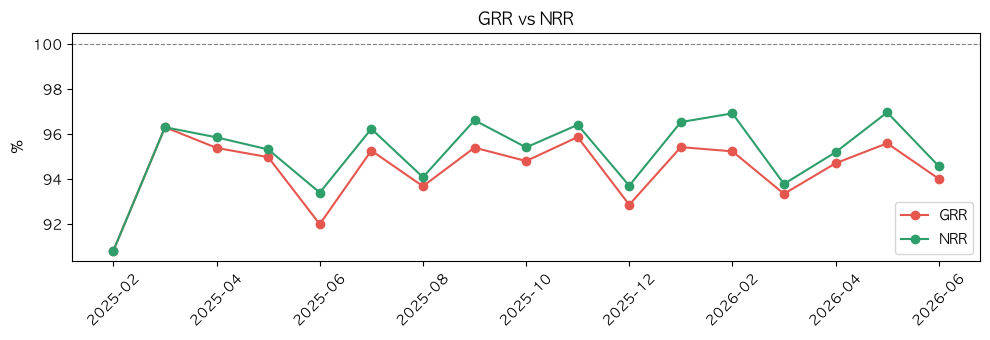

GRR 평균 94.4% / NRR 평균 95.2% / 갭 +0.73%p


In [11]:
mrr["grr"] = (mrr.baseline_mrr - mrr.churn_mrr - mrr.contraction_mrr) / mrr.baseline_mrr
mrr["nrr"] = mrr.grr + mrr.expansion_mrr / mrr.baseline_mrr

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(mrr.month, mrr.grr * 100, marker="o", color="#E5564E", label="GRR")
ax.plot(mrr.month, mrr.nrr * 100, marker="o", color="#2E9E6B", label="NRR")
ax.axhline(100, color="gray", ls="--", lw=0.8)
ax.set_ylabel("%"); ax.set_title("GRR vs NRR")
ax.set_xticks(range(0, len(mrr), 2)); ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout(); plt.show()
print(f"GRR 평균 {mrr.grr.mean():.1%} / NRR 평균 {mrr.nrr.mean():.1%} / 갭 {(mrr.nrr - mrr.grr).mean():+.2%}p")

GRR이 94% 안팎으로 이탈 방어는 양호하지만, NRR과의 갭이 1%p도 되지 않습니다.
본문에서 다룬 해석 그대로입니다 — **이탈 방어는 훌륭하지만, 업셀링으로 매출을 키우는 구조는 아직 없다**는 뜻입니다.
플랜 세분화나 부가 기능 같은 expansion 전략을 고민해야 할 단계인지 판단하는 근거가 됩니다.

## 실습 5. 사람 수와 돈을 헷갈리지 않기

같은 FULL OUTER JOIN 로직을 '구독자 수' 단위로 반복합니다. 본문 2.4.7에서 강조했듯,
**업그레이드/다운그레이드는 매출(expansion/contraction)만 바꿀 뿐 구독자 수는 바꾸지 않습니다.**
쿼리는 `sql/subscriber_counts.sql`에 있습니다.

In [12]:
query = open("sql/subscriber_counts.sql", encoding="utf-8").read()
subs = con.execute(query).df().fillna(0)
subs["month"] = pd.to_datetime(subs["month"]).dt.to_period("M").astype(str)
subs = subs.iloc[1:].reset_index(drop=True)

# 구독자 수 항등식: 이번 달 구독자 = 전월 구독자 + new + reactivation - churned
prev_subs = subs.subscribers.shift(1)
check = prev_subs + subs.new_subs + subs.reactivation_subs - subs.churned_subs
print("구독자 수 항등식 오차(첫 달 제외):", (subs.subscribers - check).abs().iloc[1:].max())
subs.tail(4)

구독자 수 항등식 오차(첫 달 제외): 0.0


,month,subscribers,new_subs,reactivation_subs,churned_subs
13,2026-03,962,120,5,55
14,2026-04,1040,122,6,50
15,2026-05,1133,130,5,42
16,2026-06,1211,133,7,62


매출 수식에는 expansion/contraction 항이 있었지만, 구독자 수 수식에는 없습니다.
그런데도 두 항등식이 모두 정확히 성립합니다 — 지금 집계하는 지표가 '사람 수'인지 '돈'인지에 따라
써야 하는 수식이 달라진다는 것을 데이터로 확인한 셈입니다.

## 실습 6. 심어 둔 정답 복원 — churn rate에서 LTV까지

이 데이터는 **월 이탈률 5%**를 심어서 생성했습니다. 우리가 분해한 MRR에서
churn rate를 계산해 이 값이 복원되는지 확인합니다. (본문 2.3의 churn rate 수식)

In [13]:
# 초기 몇 달은 코호트가 어려 churn 모수가 작으므로, 안정화된 구간으로 계산
stable = mrr[mrr.month >= "2025-04"]
churn_rate = (stable.churn_mrr / stable.baseline_mrr).mean()
print(f"복원된 월 churn rate : {churn_rate:.1%}  (가정한 값: 5%)")

# 어림식: 기대 유지 기간 ≈ 1 / churn rate (등비급수의 합), LTV ≈ ARPU / churn rate
lifetime_m = 1 / churn_rate
arpu = classified.sales_amount_krw.mean()
print(f"기대 구독 유지 기간  : {lifetime_m:.1f}개월  (≈ 1 / {churn_rate:.3f})")
print(f"인당 월매출(ARPU)    : {arpu:,.0f}원")
print(f"구독자 1인 LTV 어림  : {arpu / churn_rate:,.0f}원  (ARPU ÷ churn rate)")

복원된 월 churn rate : 5.2%  (가정한 값: 5%)
기대 구독 유지 기간  : 19.2개월  (≈ 1 / 0.052)
인당 월매출(ARPU)    : 6,237원
구독자 1인 LTV 어림  : 120,030원  (ARPU ÷ churn rate)


이탈률 5%의 역수인 20개월 근처가 복원됩니다. 매달 c의 확률로 이탈하는 유저가 각 달에 구독 중일
확률을 전부 더하면 등비급수의 합 1/c로 닫히기 때문입니다. 즉 **churn rate를 계산할 수 있으면
기대 유지 기간과 LTV의 윤곽이 잡히고**, 이 숫자는 마케팅 CAC의 상한선을 정하는 근거가 됩니다.
이 어림식이 실무에서 갖는 의미는 챕터 마지막 '정리하며'에서 한 번 더 짚습니다.
이탈률을 1%p만 낮춰도 LTV가 얼마나 움직이는지 위 식에 직접 넣어 확인해 보세요.

## 마치며

결제 로그 하나에서 시작해 유저 식별 → renew/reactivation 분류 → MRR 분해 → GRR/NRR 진단 →
구독자 수 검증 → LTV 어림까지, 본문 2장의 파이프라인을 그대로 재현했습니다.
실무에서는 여기에 체험(Trial) 전환, 연구독 안분, 환불, 비자발적 이탈 처리가 얹어집니다 —
각각의 개념과 주의점은 본문 1장, 2.4.4, 2.4.5를 참고하세요.

[내 데이터 적용] 스토어 리포트를 쓴다면 금액이 gross(수수료 차감 전)인지 net인지부터 확인하고,
결제 주기에 맞춰 실습 2의 32일 임계값을 조정하는 것부터 시작하면 됩니다.